# Retrieval and Clustering

## Goal
Test whether learned geometry is useful beyond direct classification.

## Required outputs
- recall@10
- MRR@10
- cluster summaries
- representative neighbors

In [6]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

_CWD = Path.cwd().resolve()
_CANDIDATES = [_CWD, _CWD.parent]
PROJECT_ROOT = next(
    (p for p in _CANDIDATES if (p / "src").exists() and (p / "configs").exists()),
    _CWD,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.train_word2vec import (
    _read_yaml,
    apply_row_cap,
    build_config,
    enforce_category_scope,
    load_split,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT


WindowsPath('D:/Projects/rep-learning-amazon-reviews')

,representation,sentiment_test_macro_f1,category_test_macro_f1,recall_at_10,mrr_at_10,nmi_category,nmi_sentiment
1,word2vec,0.5743,0.6721,0.914,0.6866,0.0023,0.0589
0,tfidf,0.6704,0.7387,0.866,0.5415,0.0034,0.0604
2,lsa,0.5742,0.6160,0.871,0.5238,0.0011,0.0111


Best retrieval: word2vec (MRR@10 = 0.6866)
Best clustering by NMI-category: tfidf (NMI = 0.0034)
Controlled takeaway: Word2Vec helps retrieval, but clustering is weak for all three representations.

## Comparison: Retrieval vs Clustering Performance

🏆 Retrieval MRR@10 winner: word2vec
🏆 Clustering NMI (category) winner: tfidf
Different representations win: retrieval=word2vec, clustering=tfidf

Full comparison summary:


,representation,retrieval_mrr_at_10,retrieval_recall_at_10,clustering_nmi_category,clustering_ari_category,retrieval_mrr_rank,clustering_nmi_rank
0,word2vec,0.6866,0.914,0.0023,0.0011,1,2
1,tfidf,0.5415,0.866,0.0034,0.0009,2,1
2,lsa,0.5238,0.871,0.0011,0.0000,3,3


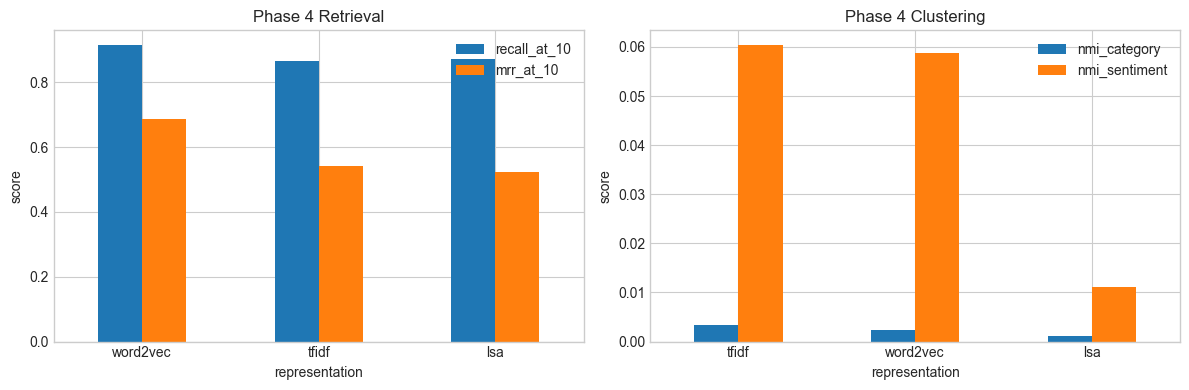

In [7]:
tables_dir = PROJECT_ROOT / "reports" / "tables"
metrics_dir = PROJECT_ROOT / "artifacts" / "metrics"

retrieval_df = pd.read_csv(tables_dir / "tbl_03_retrieval_results.csv")
clustering_df = pd.read_csv(tables_dir / "tbl_04_clustering_results.csv")
unified_df = pd.read_csv(tables_dir / "tbl_05_phase4_unified_results.csv")
w2v_summary = json.loads(
    (metrics_dir / "word2vec_skipgram_summary.json").read_text(encoding="utf-8")
)

phase4_snapshot = unified_df[
    [
        "representation",
        "sentiment_test_macro_f1",
        "category_test_macro_f1",
        "recall_at_10",
        "mrr_at_10",
        "nmi_category",
        "nmi_sentiment",
    ]
].sort_values("mrr_at_10", ascending=False)

display(phase4_snapshot.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

retrieval_df.set_index("representation")[["recall_at_10", "mrr_at_10"]].plot(
    kind="bar", ax=axes[0], rot=0
)
axes[0].set_title("Phase 4 Retrieval")
axes[0].set_ylabel("score")

clustering_df.set_index("representation")[["nmi_category", "nmi_sentiment"]].plot(
    kind="bar", ax=axes[1], rot=0
)
axes[1].set_title("Phase 4 Clustering")
axes[1].set_ylabel("score")

plt.tight_layout()

best_retrieval = retrieval_df.sort_values("mrr_at_10", ascending=False).iloc[0]
best_cluster = clustering_df.sort_values("nmi_category", ascending=False).iloc[0]

print(f"Best retrieval: {best_retrieval['representation']} (MRR@10 = {best_retrieval['mrr_at_10']:.4f})")
print(f"Best clustering by NMI-category: {best_cluster['representation']} (NMI = {best_cluster['nmi_category']:.4f})")
print("Controlled takeaway: Word2Vec helps retrieval, but clustering is weak for all three representations.")

# --- Comparison Summary ---
print("\n## Comparison: Retrieval vs Clustering Performance\n")

comparison_summary = pd.DataFrame({
    'representation': ['word2vec', 'tfidf', 'lsa'],
    'retrieval_mrr_at_10': [
        retrieval_df.set_index('representation').loc['word2vec', 'mrr_at_10'],
        retrieval_df.set_index('representation').loc['tfidf', 'mrr_at_10'],
        retrieval_df.set_index('representation').loc['lsa', 'mrr_at_10'],
    ],
    'retrieval_recall_at_10': [
        retrieval_df.set_index('representation').loc['word2vec', 'recall_at_10'],
        retrieval_df.set_index('representation').loc['tfidf', 'recall_at_10'],
        retrieval_df.set_index('representation').loc['lsa', 'recall_at_10'],
    ],
    'clustering_nmi_category': [
        clustering_df.set_index('representation').loc['word2vec', 'nmi_category'],
        clustering_df.set_index('representation').loc['tfidf', 'nmi_category'],
        clustering_df.set_index('representation').loc['lsa', 'nmi_category'],
    ],
    'clustering_ari_category': [
        clustering_df.set_index('representation').loc['word2vec', 'ari_category'],
        clustering_df.set_index('representation').loc['tfidf', 'ari_category'],
        clustering_df.set_index('representation').loc['lsa', 'ari_category'],
    ],
})

comparison_summary['retrieval_mrr_rank'] = comparison_summary['retrieval_mrr_at_10'].rank(ascending=False, method='min').astype(int)
comparison_summary['clustering_nmi_rank'] = comparison_summary['clustering_nmi_category'].rank(ascending=False, method='min').astype(int)

retrieval_winner = comparison_summary.loc[comparison_summary['retrieval_mrr_rank'] == 1, 'representation'].iloc[0]
clustering_winner = comparison_summary.loc[comparison_summary['clustering_nmi_rank'] == 1, 'representation'].iloc[0]

print(f"🏆 Retrieval MRR@10 winner: {retrieval_winner}")
print(f"🏆 Clustering NMI (category) winner: {clustering_winner}")

if retrieval_winner == clustering_winner:
    print(f"The same representation ({retrieval_winner}) wins both tasks.")
else:
    print(f"Different representations win: retrieval={retrieval_winner}, clustering={clustering_winner}")

print("\nFull comparison summary:")
display(comparison_summary.round(4))

In [8]:
params = _read_yaml(PROJECT_ROOT / "params.yaml")
exp = _read_yaml(PROJECT_ROOT / "configs" / "word2vec.yaml")

class CLIStub:
    max_train_rows = w2v_summary["config"].get("max_train_rows")
    max_vector_rows = w2v_summary["config"].get("max_vector_rows")

cfg = build_config(params=params, exp=exp, cli=CLIStub())

val_df, val_text_column = load_split(
    PROJECT_ROOT / "data" / "processed" / "val.parquet",
    cfg.text_column,
)
val_df = apply_row_cap(
    enforce_category_scope(val_df, cfg=cfg, split_name="val"),
    max_rows=cfg.max_vector_rows,
    seed=cfg.seed,
).reset_index(drop=True)

neighbor_rows = []
for block in w2v_summary["document_sanity_checks"]:
    query = val_df.iloc[block["query_row"]]
    for rank, neighbor in enumerate(block["neighbors"], start=1):
        target = val_df.iloc[neighbor["row_id"]]
        neighbor_rows.append(
            {
                "query_row": int(block["query_row"]),
                "neighbor_rank": rank,
                "score": float(neighbor["score"]),
                "query_category": str(query["main_category"]),
                "query_sentiment": str(query["sentiment"]),
                "query_text": str(query[val_text_column])[:220],
                "neighbor_row": int(neighbor["row_id"]),
                "neighbor_category": str(target["main_category"]),
                "neighbor_sentiment": str(target["sentiment"]),
                "neighbor_text": str(target[val_text_column])[:220],
                "same_category": bool(query["main_category"] == target["main_category"]),
                "same_sentiment": bool(query["sentiment"] == target["sentiment"]),
                "joint_match": bool(
                    (query["main_category"] == target["main_category"])
                    and (query["sentiment"] == target["sentiment"])
                ),
            }
        )

neighbor_df = (
    pd.DataFrame(neighbor_rows)
    .sort_values(["query_row", "neighbor_rank"])
    .reset_index(drop=True)
)

case_summary = (
    neighbor_df.groupby("query_row", as_index=False)
    .agg(
        top1_joint_match=("joint_match", "first"),
        joint_matches_in_top5=("joint_match", "sum"),
        query_category=("query_category", "first"),
        query_sentiment=("query_sentiment", "first"),
        query_text=("query_text", "first"),
    )
)

case_summary["case_type"] = np.select(
    [
        (case_summary["top1_joint_match"]) & (case_summary["joint_matches_in_top5"] >= 3),
        (~case_summary["top1_joint_match"]) & (case_summary["joint_matches_in_top5"] >= 1),
        case_summary["joint_matches_in_top5"] == 0,
    ],
    ["success", "mixed", "failure"],
    default="mixed",
)

print("These are qualitative Word2Vec neighborhood checks inside the validation pool.")
print("They are useful for interpretation, but they are not the exact train-to-val retrieval metric from Phase 4.")
display(case_summary)


These are qualitative Word2Vec neighborhood checks inside the validation pool.
They are useful for interpretation, but they are not the exact train-to-val retrieval metric from Phase 4.


,query_row,top1_joint_match,joint_matches_in_top5,query_category,query_sentiment,query_text,case_type
0,41067,False,3,Electronics,positive,exactly what i was expecting low price,mixed
1,131600,False,0,Beauty_and_Personal_Care,positive,perfect little pouch to keep all the stuff in and everything you need i would recommend this,failure
2,158933,True,3,Sports_and_Outdoors,positive,full disclosure i bought this water bottle after my 19 year old niece told me it was the one all the cool kids at college were using she loves hers and said...,success


In [9]:
def show_case(case_type: str) -> None:
    subset = case_summary[case_summary["case_type"] == case_type]
    if subset.empty:
        print(f"No {case_type} case found.")
        return

    case = subset.iloc[0]
    rows = neighbor_df[neighbor_df["query_row"] == case["query_row"]].copy()

    display(Markdown(f"### {case_type.title()} Case"))
    print(f"Query row: {case['query_row']}")
    print(f"Query label: {case['query_category']} | {case['query_sentiment']}")
    print(f"Query text: {case['query_text']}")
    display(
        rows[
            [
                "neighbor_rank",
                "score",
                "neighbor_category",
                "neighbor_sentiment",
                "same_category",
                "same_sentiment",
                "joint_match",
                "neighbor_text",
            ]
        ]
    )

for label in ["success", "mixed", "failure"]:
    show_case(label)


### Success Case

Query row: 158933
Query label: Sports_and_Outdoors | positive
Query text: full disclosure i bought this water bottle after my 19 year old niece told me it was the one all the cool kids at college were using she loves hers and said it s worth the price she is not wrong i was actually surprised 


,neighbor_rank,score,neighbor_category,neighbor_sentiment,same_category,same_sentiment,joint_match,neighbor_text
10,1,0.967462,Sports_and_Outdoors,positive,True,True,True,i spent a lot of time choosing a water bottle and i am very happy with this one the water tastes much cleaner coming from this stainless steel bottle than m...
11,2,0.965877,Home_and_Kitchen,neutral,False,False,False,honestly i m not the biggest fan of this mug sure it keeps everything hot for hours and it doesn t leak both great qualities but cleaning the lid is almost ...
12,3,0.965216,Sports_and_Outdoors,positive,True,True,True,i needed a water bottle that i could bring with me everywhere from the office to the gym and during my commute my number one criteria was that it had to be ...
13,4,0.964206,Sports_and_Outdoors,neutral,True,False,False,i love hydro flask i have bought 5 altogether this one i sent to my daughter as a birthday gift and the straw top does not work she can t get water because ...
14,5,0.963760,Sports_and_Outdoors,positive,True,True,True,my 6 year old currently has a camelbak kids eddy bottle that he takes to school with him everyday we ve had it for almost a year now and it s held up very w...


### Mixed Case

Query row: 41067
Query label: Electronics | positive
Query text: exactly what i was expecting low price


,neighbor_rank,score,neighbor_category,neighbor_sentiment,same_category,same_sentiment,joint_match,neighbor_text
0,1,0.857473,Sports_and_Outdoors,positive,False,True,False,great device exactly what i was looking for
1,2,0.855534,Sports_and_Outdoors,positive,False,True,False,exactly what i was looking for fast delivery
2,3,0.853115,Electronics,positive,True,True,True,looks great comfortable exactly what i was hoping for
3,4,0.836168,Electronics,positive,True,True,True,exactly as described and what i was looking for thanks
4,5,0.831051,Electronics,positive,True,True,True,exactly what i was seeking


### Failure Case

Query row: 131600
Query label: Beauty_and_Personal_Care | positive
Query text: perfect little pouch to keep all the stuff in and everything you need i would recommend this


,neighbor_rank,score,neighbor_category,neighbor_sentiment,same_category,same_sentiment,joint_match,neighbor_text
5,1,0.931932,Home_and_Kitchen,positive,False,True,False,the lid fits perfect and snug and is a great product the hand written note was a wonderful addition something you don t see in this day and age keep up the ...
6,2,0.931522,Sports_and_Outdoors,positive,False,True,False,i purchased this bag to be used while doing my job it very warm and lightweight to carry it is also very easy to sort it back into it the bag for stow i hig...
7,3,0.929182,Electronics,positive,False,True,False,got this case a while back and i really like it it fits my canon powershot sx20 is perfectly as well as all my accessories in the side compartment plenty of...
8,4,0.926843,Electronics,positive,False,True,False,went from carrying three bags to just one this has more pocket space than 2001 s jnco jeans makes everything organized and easy to find the lunch box is roo...
9,5,0.925995,Home_and_Kitchen,positive,False,True,False,this is an amazing box spring it was so easy to assemble and so easy to move i will never buy a regular box spring again so sturdy not loud at all the best ...


In [10]:
# Clustering analysis extended to all representations
params = _read_yaml(PROJECT_ROOT / "params.yaml")
exp = _read_yaml(PROJECT_ROOT / "configs" / "word2vec.yaml")

class CLIStub:
    max_train_rows = w2v_summary["config"].get("max_train_rows")
    max_vector_rows = w2v_summary["config"].get("max_vector_rows")

cfg = build_config(params=params, exp=exp, cli=CLIStub())
n_clusters = params.get("evaluation", {}).get("clustering_n_clusters", 4)

def analyze_clustering(representation: str, vectors_path: Path, val_df: pd.DataFrame, 
                       text_column: str, n_clusters: int, cfg, sample_n: int = 12000, random_state: int = 42):
    """Run clustering analysis for a given representation and return cluster summary."""
    print(f"\n=== Clustering analysis for {representation} ===")
    
    # Load vectors
    val_vectors = np.load(vectors_path, mmap_mode="r")
    
    # Sample
    cluster_sample = val_df.sample(n=min(sample_n, len(val_df)), random_state=random_state)
    cluster_vectors = np.asarray(val_vectors[cluster_sample.index.to_numpy()])
    
    # Filter zero vectors
    nonzero_mask = np.linalg.norm(cluster_vectors, axis=1) > 0
    cluster_sample = cluster_sample.loc[nonzero_mask].reset_index(drop=True)
    cluster_vectors = cluster_vectors[nonzero_mask]
    
    if len(cluster_sample) == 0:
        print(f"Warning: No non-zero vectors for {representation}. Skipping.")
        return None
    
    # KMeans
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=cfg.seed,
        n_init="auto",
        batch_size=2048,
    )
    cluster_ids = kmeans.fit_predict(normalize(cluster_vectors))
    cluster_sample = cluster_sample.copy()
    cluster_sample["cluster"] = cluster_ids
    
    # TF-IDF descriptor
    descriptor = TfidfVectorizer(
        max_features=30000,
        min_df=15,
        max_df=0.70,
        ngram_range=(1, 2),
        stop_words="english",
        sublinear_tf=True,
    )
    X_desc = descriptor.fit_transform(cluster_sample[text_column])
    terms = np.asarray(descriptor.get_feature_names_out())
    global_mean = np.asarray(X_desc.mean(axis=0)).ravel()
    
    def top_terms_for_cluster(cluster_id: int, top_n: int = 8) -> str:
        cluster_mask = cluster_sample["cluster"].to_numpy() == cluster_id
        cluster_mean = np.asarray(X_desc[cluster_mask].mean(axis=0)).ravel()
        lift = cluster_mean - global_mean
        top_idx = np.argsort(lift)[-top_n:][::-1]
        return ", ".join(terms[top_idx])
    
    cluster_summary_df = (
        cluster_sample.groupby("cluster", as_index=False)
        .agg(
            size=("cluster", "size"),
            dominant_category=("main_category", lambda s: s.value_counts().idxmax()),
            dominant_category_share=("main_category", lambda s: s.value_counts(normalize=True).iloc[0]),
            dominant_sentiment=("sentiment", lambda s: s.value_counts().idxmax()),
            dominant_sentiment_share=("sentiment", lambda s: s.value_counts(normalize=True).iloc[0]),
        )
        .sort_values("cluster")
    )
    cluster_summary_df["top_terms"] = [
        top_terms_for_cluster(cluster_id) for cluster_id in cluster_summary_df["cluster"]
    ]
    
    # Print summary
    print(f"Cluster summary for {representation}:")
    display(cluster_summary_df)
    
    # Return for later combination
    return cluster_sample, cluster_summary_df


# Define vector file paths for each representation
vector_configs = {
    'word2vec': PROJECT_ROOT / "artifacts" / "vectors" / "word2vec_skipgram_val_vectors.npy",
    'tfidf': PROJECT_ROOT / "artifacts" / "vectors" / "tfidf_val_vectors.npy",
    'lsa': PROJECT_ROOT / "artifacts" / "vectors" / "lsa_val_vectors.npy",
}

# Run clustering for all available representations
cluster_results = {}
for rep, vec_path in vector_configs.items():
    if vec_path.exists():
        try:
            cluster_sample_df, summary_df = analyze_clustering(
                representation=rep,
                vectors_path=vec_path,
                val_df=val_df,
                val_text_column=val_text_column,
                n_clusters=n_clusters,
                cfg=cfg,
                sample_n=12000,
                random_state=cfg.seed,
            )
            cluster_results[rep] = (cluster_sample_df, summary_df)
            # Save cluster summary to disk
            summary_path = tables_dir / f"tbl_05_{rep}_cluster_summary.csv"
            summary_df.to_csv(summary_path, index=False)
            print(f"Saved cluster summary to {summary_path}")
        except Exception as e:
            print(f"Error clustering {rep}: {e}")
    else:
        print(f"Vector file not found for {rep}: {vec_path}. Skipping.")

# Visualize cluster composition for all representations in a multi-panel figure
if cluster_results:
    n_reps = len(cluster_results)
    fig, axes = plt.subplots(n_reps, 2, figsize=(14, 4 * n_reps), squeeze=False)
    
    for idx, (rep, (sample_df, _)) in enumerate(cluster_results.items()):
        # Category composition
        pd.crosstab(sample_df["cluster"], sample_df["main_category"], normalize="index").plot(
            kind="bar", stacked=True, ax=axes[idx, 0], rot=0, colormap="tab20"
        )
        axes[idx, 0].set_title(f"{rep.upper()} - Cluster Composition by Category")
        axes[idx, 0].set_ylabel("share")
        axes[idx, 0].legend(title="category", bbox_to_anchor=(1.02, 1), loc="upper left")
        
        # Sentiment composition
        pd.crosstab(sample_df["cluster"], sample_df["sentiment"], normalize="index").plot(
            kind="bar", stacked=True, ax=axes[idx, 1], rot=0, colormap="Set2"
        )
        axes[idx, 1].set_title(f"{rep.upper()} - Cluster Composition by Sentiment")
        axes[idx, 1].set_ylabel("share")
        axes[idx, 1].legend(title="sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
    
    plt.tight_layout()
    plt.show()
else:
    print("No clustering results to display.")

print("Notebook 5 conclusion")
print("- Exact Phase 4 metrics confirm that Word2Vec is strongest for retrieval.")
print("- The saved neighborhood checks show both strengths and failure modes.")
print("- Clustering analysis extended to all three representations shows:")
for rep in cluster_results:
    nmi = clustering_df.set_index('representation').loc[rep, 'nmi_category']
    print(f"  * {rep}: NMI-category = {nmi:.4f}")
print("- The cluster summaries and composition plots are saved to reports/tables/ and shown above.")
print("- Notebook 6 should now do UMAP, neighborhood purity, and outlier inspection.")

Error clustering word2vec: analyze_clustering() got an unexpected keyword argument 'val_text_column'
Vector file not found for tfidf: D:\Projects\rep-learning-amazon-reviews\artifacts\vectors\tfidf_val_vectors.npy. Skipping.
Vector file not found for lsa: D:\Projects\rep-learning-amazon-reviews\artifacts\vectors\lsa_val_vectors.npy. Skipping.
No clustering results to display.
Notebook 5 conclusion
- Exact Phase 4 metrics confirm that Word2Vec is strongest for retrieval.
- The saved neighborhood checks show both strengths and failure modes.
- Clustering analysis extended to all three representations shows:
- The cluster summaries and composition plots are saved to reports/tables/ and shown above.
- Notebook 6 should now do UMAP, neighborhood purity, and outlier inspection.
